<a href="https://colab.research.google.com/github/reehabjahangir3-coder/THzScattering/blob/main/FFT_Teraflash.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fast Fourier Transformation of Terahertz Time-Domain Pulses into Frequency Domain with modified Blackmann Windowing



In [20]:
#Import packages

import pandas as pd
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt

## 1. Load Data into a pandas framework

(Validate algorithm by comparing with Teraflash software FFT)


In [21]:
pulse_df = pd.read_csv('/content/air_70ps.pulse.csv')
print("Pulse Data (first 5 rows):")
display(pulse_df.head())

#Comment out below line if no spectr.csv file is present

spectr_df = pd.read_csv('/content/air_70ps.spectr.csv')
print("\nSpectra Data (first 5 rows):")
display(spectr_df.head())

Pulse Data (first 5 rows):


,Time_abs/ps,Signal/nA
0,1100.00,0.078016
1,1100.05,0.033293
2,1100.10,0.001427
3,1100.15,-0.036264
4,1100.20,-0.076472



Spectra Data (first 5 rows):


,Frequency/GHz,Amplitude rel.,Phase
0,0.0,0.00681,0.00000
1,14.3,0.01460,0.96199
2,28.6,0.00911,2.38468
3,42.8,0.00867,4.73877
4,57.1,0.00762,5.67664


## 2. Apply a Windowing Function
### Measured signal starts/stops abruptly, and windowing reduces edge discontinuities, spectra leakages, improves numerical stability and allows isolation of useful part of signal.

### Modified Blackmann Window

Traperzoidal windows are a good choice for when true amplitude is important, minimally distorting main pulse and some degree of leakage reduction is needed.

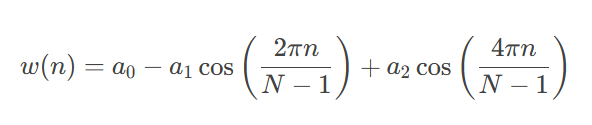

Tapered/Trapezoidal Window that builds an array with three regions: a rising edge, a flat middle and a falling edge.

### Define Blackmann Windowing Function

#### Parameters

1.    n(int) : Total Length of window
2.   relativewidth_start (float): fraction of n for taper at the start (0-1) {only tapers the first part}
3.   relativewidth_end (float): fraction of n for taper at the end (0-1)
{only tapers the last part}
4.   alpha = 0.16 (standard Blackman parameter)

The width of the window depends on the scan range: 50 ps needs a window of 2 ps (40 points), and longer ranges need a window of 10 ps (200 points) at the end (modify parameter 3 according to scan range)








In [22]:
import numpy as np

def modblackmanwindow(n, relativewidth_start, relativewidth_end):
    """
    Returns a modified Blackman window vector (values between 0 and 1).
    """

    alpha = 0.16
    w = np.ones(n)

    width_start = int(np.floor(relativewidth_start * n))
    width_end = int(np.floor(relativewidth_end * n))

    # Start taper
    if width_start >= 1:
        nrel = np.arange(0, width_start) / (2 * width_start - 1)
        w[:width_start] = 0.5 * (
            1 - alpha
            - np.cos(2 * np.pi * nrel)
            + alpha * np.cos(4 * np.pi * nrel)
        )

    # End taper
    if width_end >= 1:
        nrel = np.arange(width_end, 2 * width_end) / (2 * width_end - 1)
        w[n - width_end:] = 0.5 * (
            1 - alpha
            - np.cos(2 * np.pi * nrel)
            + alpha * np.cos(4 * np.pi * nrel)
        )

    return w

## 3. Perform FFT on Pulse Data

Fourier Transform (FT) related the time domain of a signal to its frequency domain, where the frequency domain contains the information about the sinusoids (amplitude, frequency, phase) that construct the signal.

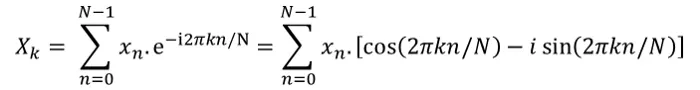




#### X[n] = time-domain values
#### X[k] = frequency domain values
#### N = total samples


#### Parameters

1. N = number of sampling points
2. T = Sample Spacing
3. signal_windowed = Modified Blackmann Window is applied to the signal

In [78]:
import numpy as np

# Extract time and signal data
pulse_df.columns = pulse_df.columns.str.strip() # Clean column names by stripping whitespace
time = pulse_df['Time_abs/ps'].values * 1e-12  # Convert ps to seconds
signal = pulse_df['Signal/nA'].values

# Number of sample points
N = len(signal)
# Sample spacing
T = time[1] - time[0]

# Apply modified Blackman window using the defined function ---
# 2 ps/ 40 points for 50 ps scan range and 10 ps/ 200 points for longer scan ranges
start_window_duration_s = 1e-12 # From previous context
end_window_duration_s = 10e-12  # From previous context

#Define width
num_samples_start_window = int(start_window_duration_s / T)
num_samples_end_window = int(end_window_duration_s / T)

#Width of modified Blackman window is adapted to scan range -
relativewidth_start = num_samples_start_window / N
relativewidth_end = num_samples_end_window / N

window = modblackmanwindow(N, relativewidth_start, relativewidth_end)

# Apply the window to the signal
signal_windowed = signal * window
# ----------------------------------------------------------------

# Perform FFT on the windowed signal
yf = fft(signal_windowed)
# Calculate frequency from sampling frequency and FFT size
xf = fftfreq(N, T)

# Get positive frequencies and corresponding amplitudes/phases
positive_frequencies = xf[xf >= 0]
positive_yf = yf[xf >= 0]

# Calculate amplitude (magnitude)
amplitude = np.abs(positive_yf)

# Normalize amplitude: Divide by N for DC component, 2/N for others (for single-sided spectrum)
amplitude[0] = amplitude[0] / N  # DC component
amplitude[1:] = 2 * amplitude[1:] / N # Non-DC components

# Calculate phase (radians) - output is in [-pi, pi]
phase_radians = np.arctan2(positive_yf.imag, positive_yf.real)

# Unwrap phase (radians)
phase_unwrapped_radians = np.unwrap(phase_radians)

#Make phase positive and subtract/add 2*PI for since FFT sometimes does not distinguish correctly
phase_unwrapped_radians = -(phase_unwrapped_radians - 2*np.pi)

# Convert frequency to GHz
frequency_ghz = positive_frequencies / 1e9

# Create a DataFrame for FFT results
fft_df = pd.DataFrame({
    'Frequency/GHz': frequency_ghz,
    'Amplitude': amplitude,
    'Phase (rad)': phase_radians, # Wrapped phase in radians (-pi to pi)
    'Phase (unwrapped rad)': phase_unwrapped_radians # Unwrapped phase in radians
})

print("FFT Results (first 5 rows):")
display(fft_df.head())

FFT Results (first 5 rows):


,Frequency/GHz,Amplitude,Phase (rad),Phase (unwrapped rad)
0,0.000000,0.573061,-3.141593,9.424778
1,14.275517,0.367629,-0.420286,6.703472
2,28.551035,0.157288,1.255366,5.027819
3,42.826552,0.194342,2.250002,4.033184
4,57.102070,0.274513,-0.365135,6.648321


## 4. Normalize FFT Amplitude to 1
1. Interpolate the calculated FFT amplitude to the frequency points of the reference spectrum
2. Normalize its maximum value to 1

In [79]:
fft_df['Amplitude (normalized)'] = fft_df['Amplitude'] / fft_df['Amplitude'].max()

print("FFT Results with Normalized Amplitude (first 5 rows):")
display(fft_df.head())

FFT Results with Normalized Amplitude (first 5 rows):


,Frequency/GHz,Amplitude,Phase (rad),Phase (unwrapped rad),Amplitude (normalized)
0,0.000000,0.573061,-3.141593,9.424778,0.045994
1,14.275517,0.367629,-0.420286,6.703472,0.029506
2,28.551035,0.157288,1.255366,5.027819,0.012624
3,42.826552,0.194342,2.250002,4.033184,0.015598
4,57.102070,0.274513,-0.365135,6.648321,0.022032


## 5. Plot results and compare amplitude spectra with reference FFT

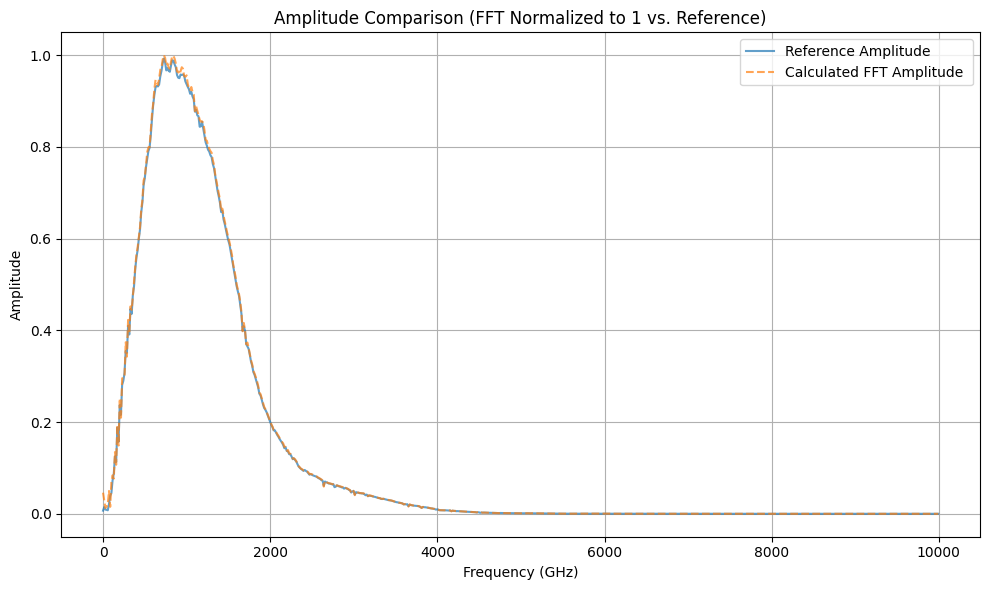

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.interpolate import interp1d

# Get the frequency points from the reference spectrum (spectr_df)
reference_frequencies = spectr_df['Frequency/GHz']

# Create an interpolation function for the normalized FFT amplitude

f_interp = interp1d(
    fft_df['Frequency/GHz'],
    fft_df['Amplitude (normalized)'],
    kind='linear',
    bounds_error=False, # Allow extrapolation/fill for out-of-bounds
    fill_value=0 # Fill with 0 for points outside the FFT frequency range
)

# Interpolate the FFT amplitude to the reference frequency points
interpolated_fft_amplitude = f_interp(reference_frequencies)

# Create the comparison DataFrame
normalized_comparison_df = pd.DataFrame({
    'Frequency/GHz': reference_frequencies,
    'Reference Amplitude': spectr_df[' Amplitude rel.'],
    'FFT Amplitude (Normalized to 1)': interpolated_fft_amplitude
})

plt.figure(figsize=(10, 6))
sns.lineplot(x='Frequency/GHz', y='Reference Amplitude', data=normalized_comparison_df, label='Reference Amplitude', alpha=0.7)
sns.lineplot(x='Frequency/GHz', y='FFT Amplitude (Normalized to 1)', data=normalized_comparison_df, label='Calculated FFT Amplitude ', alpha=0.7, linestyle='--')
plt.title('Amplitude Comparison (FFT Normalized to 1 vs. Reference)')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Plot results and compare phase spectra with reference FFT

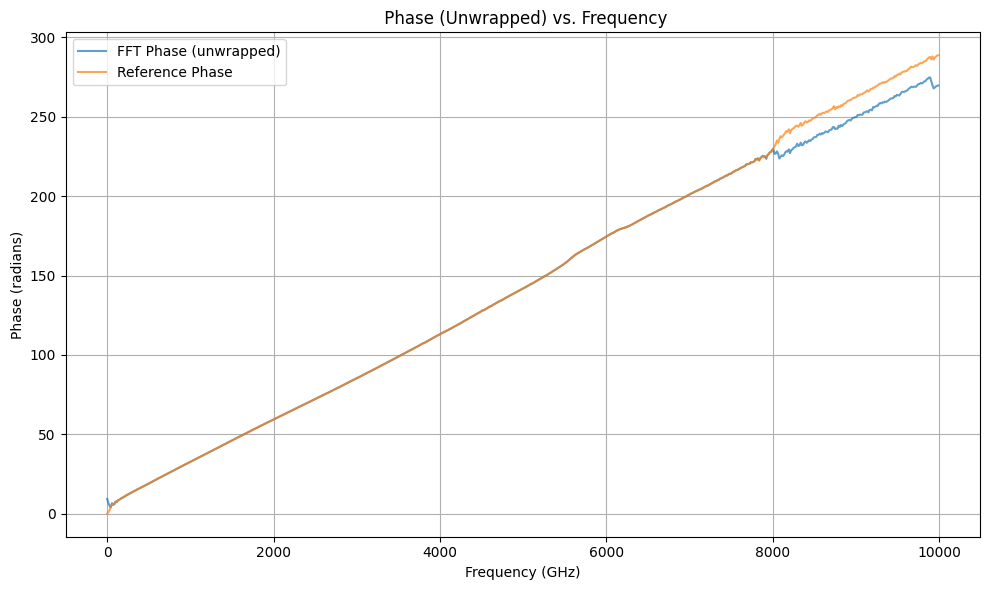

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.lineplot(x='Frequency/GHz', y='Phase (unwrapped rad)', data=fft_df, label='FFT Phase (unwrapped)', alpha=0.7)
sns.lineplot(x='Frequency/GHz', y=' Phase', data=spectr_df, label='Reference Phase', alpha=0.7)
plt.title(' Phase (Unwrapped) vs. Frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Phase (radians)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

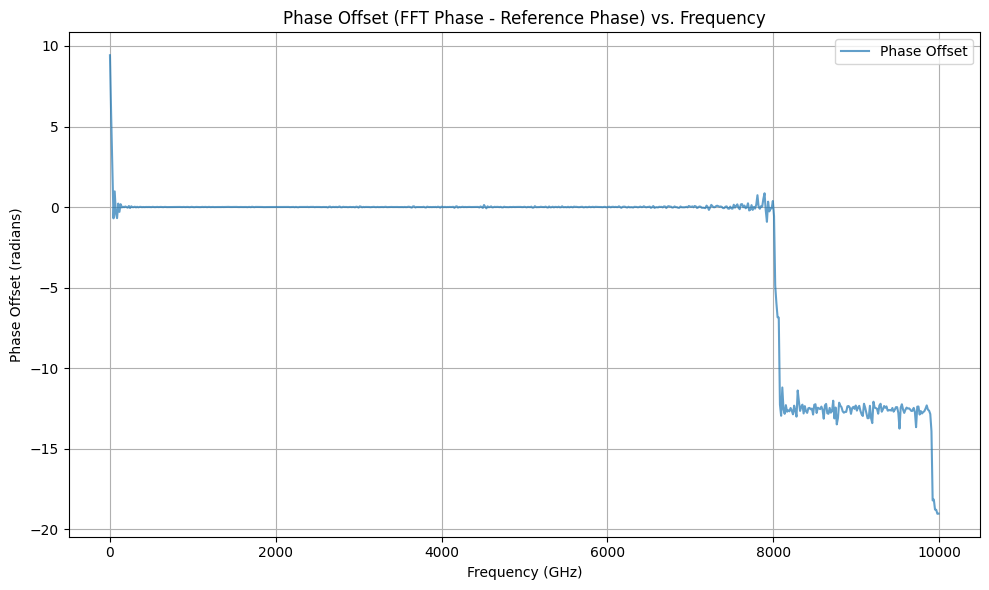

In [82]:
from scipy.interpolate import interp1d

# Get the frequency points from the reference spectrum (spectr_df)
reference_frequencies = spectr_df['Frequency/GHz']

# Create an interpolation function for the unwrapped FFT phase
f_interp_phase = interp1d(
    fft_df['Frequency/GHz'],
    fft_df['Phase (unwrapped rad)'],
    kind='linear',
    bounds_error=False, # Allow extrapolation/fill for out-of-bounds
    fill_value='extrapolate' # Extrapolate for points outside the FFT frequency range
)

# Interpolate the FFT phase to the reference frequency points
interpolated_fft_phase = f_interp_phase(reference_frequencies)

# Create a DataFrame for phase comparison
phase_comparison_df = pd.DataFrame({
    'Frequency/GHz': reference_frequencies,
    'Reference Phase': spectr_df[' Phase'],
    'FFT Phase (Unwrapped)': interpolated_fft_phase
})

# Calculate the phase offset
phase_comparison_df['Phase Offset (rad)'] = phase_comparison_df['FFT Phase (Unwrapped)'] - phase_comparison_df['Reference Phase']

plt.figure(figsize=(10, 6))
sns.lineplot(x='Frequency/GHz', y='Phase Offset (rad)', data=phase_comparison_df, label='Phase Offset', alpha=0.7)
plt.title('Phase Offset (FFT Phase - Reference Phase) vs. Frequency')
plt.xlabel('Frequency (GHz)')
plt.ylabel('Phase Offset (radians)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()